<a href="https://colab.research.google.com/github/Conte2004/Data-Analytics-2-/blob/main/Data_StoryTelling__COVID_19_Contegiacomo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Storytelling - COVID-19 en Estados Unidos

**Alumno:** Contegiacomo  
**Curso:** Coderhouse - Data Analytics  
**Fecha:** Agosto 2025
**Comisión:** 75690

Este proyecto analiza datos de COVID-19 en los estados de EE.UU. con el objetivo de obtener insights relevantes para la toma de decisiones sanitarias. Utiliza datos históricos de una base pública enriquecida con información actual obtenida vía API.

##  Objetivo general:
Analizar el impacto del COVID-19 a nivel estatal en EE.UU., identificando patrones en contagios, hospitalizaciones, muertes y testeo, mediante técnicas de análisis exploratorio y visualizaciones.

##  Audiencia objetivo:
Profesionales del sector salud, autoridades gubernamentales, analistas y tomadores de decisiones en gestión sanitaria.



# Carga y Exploración Inical de Datos

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuraciones generales
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Cargar dataset
df = pd.read_csv("/content/all-states-history.csv")

# Vista general
df.head()

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110


In [3]:
# Convertir columna de fecha a tipo datetime
df['date'] = pd.to_datetime(df['date'])

# Revisar valores faltantes por columna
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

,0
positiveTestsPeopleAntigen,20147
negativeTestsPeopleAntibody,19808
totalTestsPeopleAntigen,19781
positiveTestsPeopleAntibody,19686
onVentilatorCumulative,19490
negativeTestsAntibody,19322
totalTestsPeopleAntibody,18580
positiveTestsAntigen,18547
positiveTestsAntibody,17434
totalTestsAntigen,17359


##  **Hipótesis planteadas**:

1. Algunos estados presentaron significativamente más hospitalizaciones que otros debido a su densidad poblacional y políticas sanitarias.
2. Los casos positivos siguieron un patrón de crecimiento similar en los estados más afectados.
3. Existe una correlación positiva entre cantidad de pruebas y positivos detectados.
4. La tasa de mortalidad fue más alta en estados con menor infraestructura hospitalaria.
5. Las olas de contagios se reflejan directamente en el uso de UCI y ventiladores.


## **Preguntas de interés**

1. ¿Qué estados tuvieron los mayores picos de hospitalización?
2. ¿Cómo evolucionaron los casos positivos a lo largo del tiempo en los 5 estados más afectados?
3. ¿Hay relación entre el número de pruebas realizadas y los casos positivos detectados?
4. ¿Qué estados tuvieron las tasas de mortalidad más altas (muertes / positivos)?
5. ¿Cómo fue la evolución del uso de ventiladores e ingresos a UCI a lo largo del tiempo?


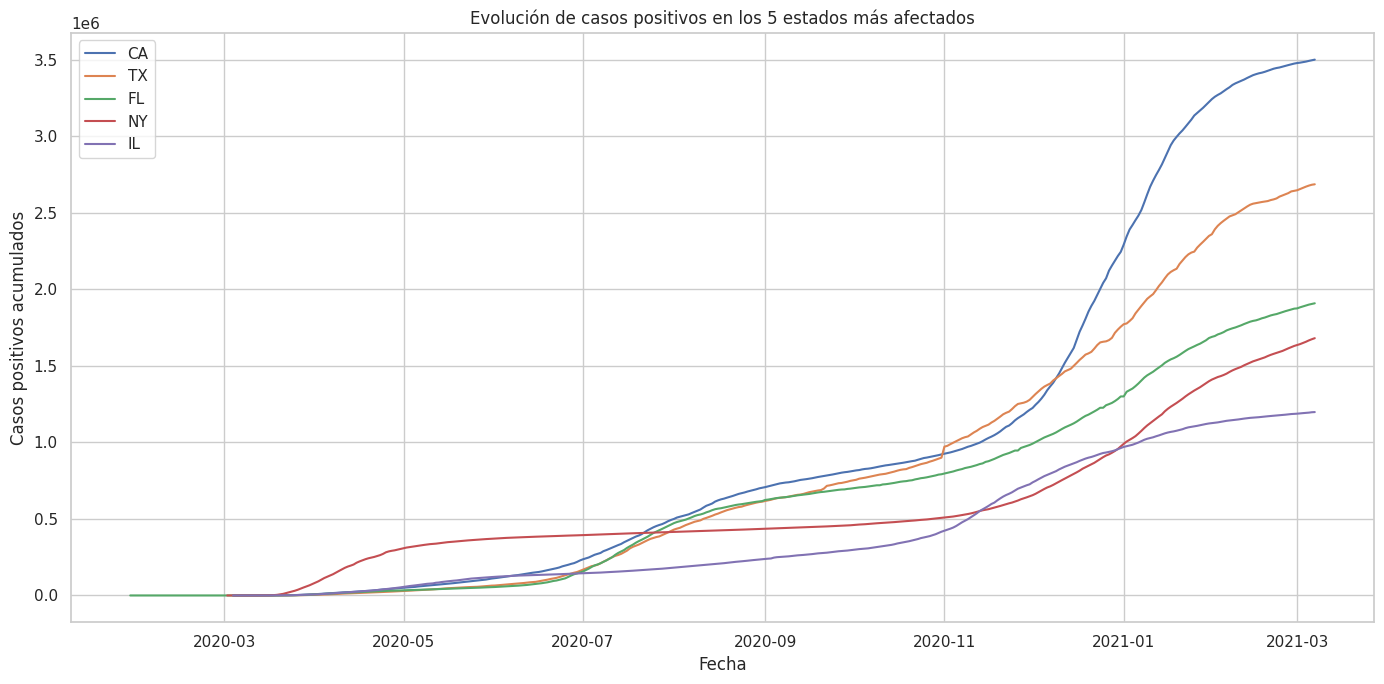

In [4]:
# Evolución de casos positivos en los 5 estados con más casos acumulados
top_states = df.groupby("state")["positive"].max().sort_values(ascending=False).head(5).index.tolist()
df_top_states = df[df["state"].isin(top_states)]

plt.figure(figsize=(14, 7))
for state in top_states:
    state_data = df_top_states[df_top_states["state"] == state]
    plt.plot(state_data["date"], state_data["positive"], label=state)

plt.title("Evolución de casos positivos en los 5 estados más afectados")
plt.xlabel("Fecha")
plt.ylabel("Casos positivos acumulados")
plt.legend()
plt.tight_layout()
plt.show()

### 1. Estados con mayores picos de hospitalización

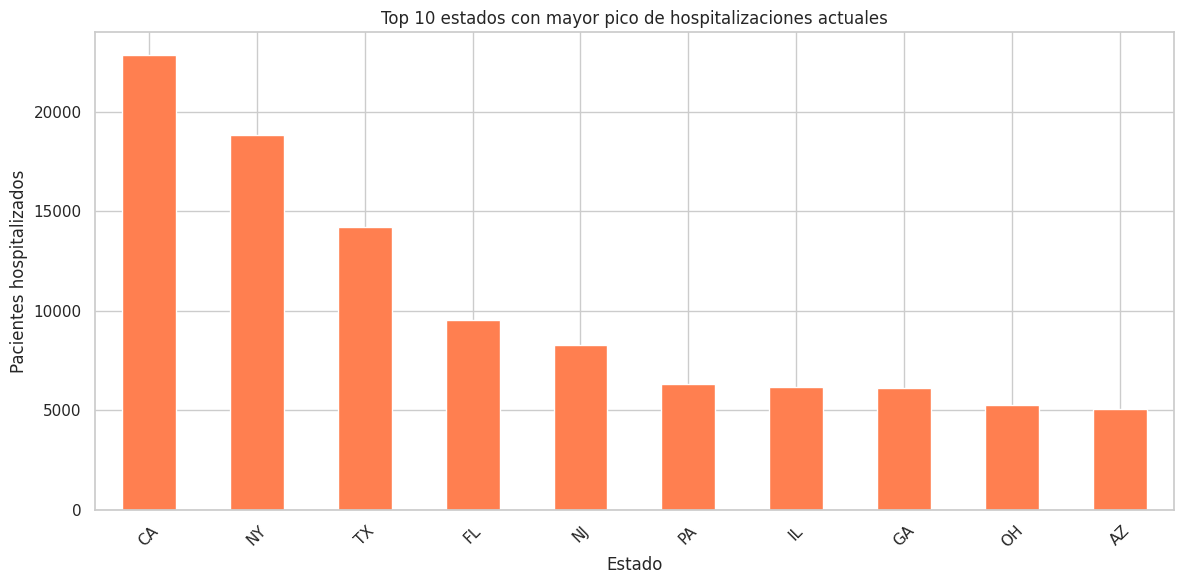

In [5]:
# Máximo valor de hospitalizaciones por estado
hospital_peaks = df.groupby("state")["hospitalizedCurrently"].max().sort_values(ascending=False).head(10)
hospital_peaks.plot(kind="bar", color="coral")
plt.title("Top 10 estados con mayor pico de hospitalizaciones actuales")
plt.ylabel("Pacientes hospitalizados")
plt.xlabel("Estado")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Evolución de casos positivos diarios en los estados más afectados

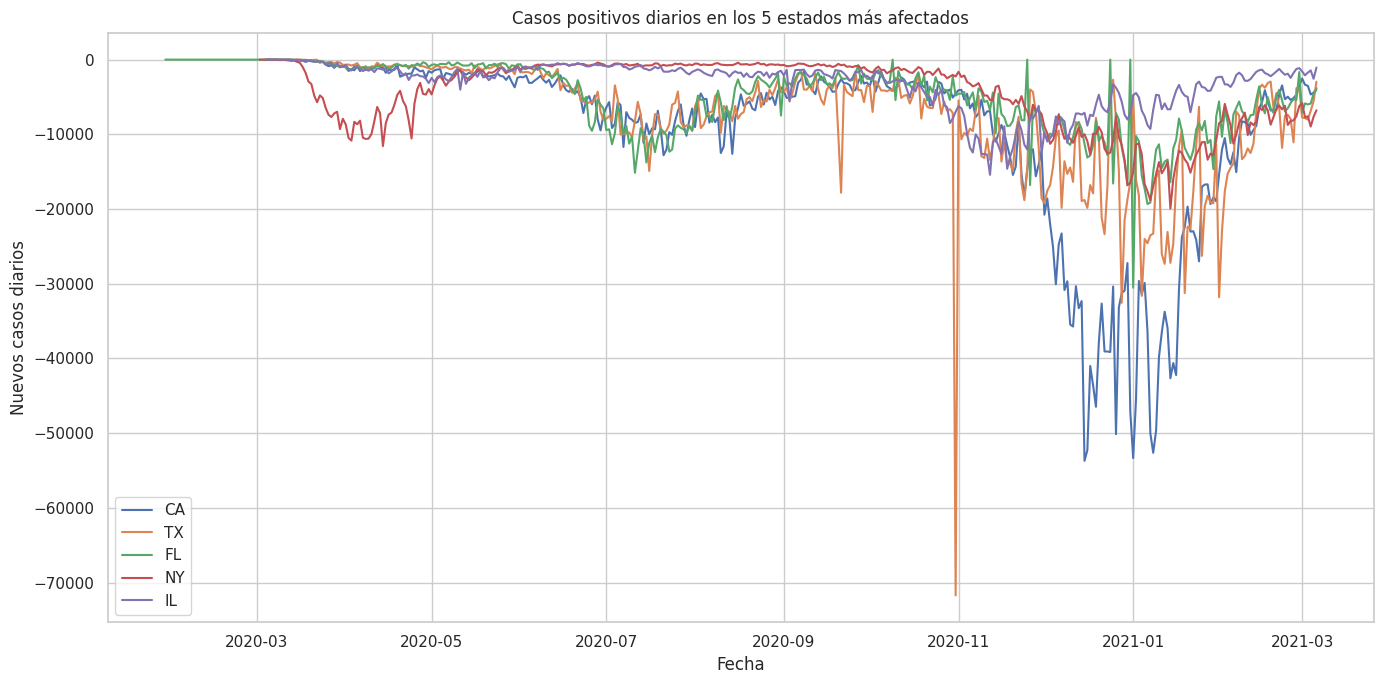

In [6]:
# Calcular nuevos casos diarios
df['positiveIncrease'] = df.groupby("state")["positive"].diff()

# Filtrar estados top
df_top_states_daily = df[df["state"].isin(top_states)]

# Plot
plt.figure(figsize=(14, 7))
for state in top_states:
    state_data = df_top_states_daily[df_top_states_daily["state"] == state]
    plt.plot(state_data["date"], state_data["positiveIncrease"], label=state)

plt.title("Casos positivos diarios en los 5 estados más afectados")
plt.xlabel("Fecha")
plt.ylabel("Nuevos casos diarios")
plt.legend()
plt.tight_layout()
plt.show()

### 3. Relación entre el número de pruebas y casos positivos

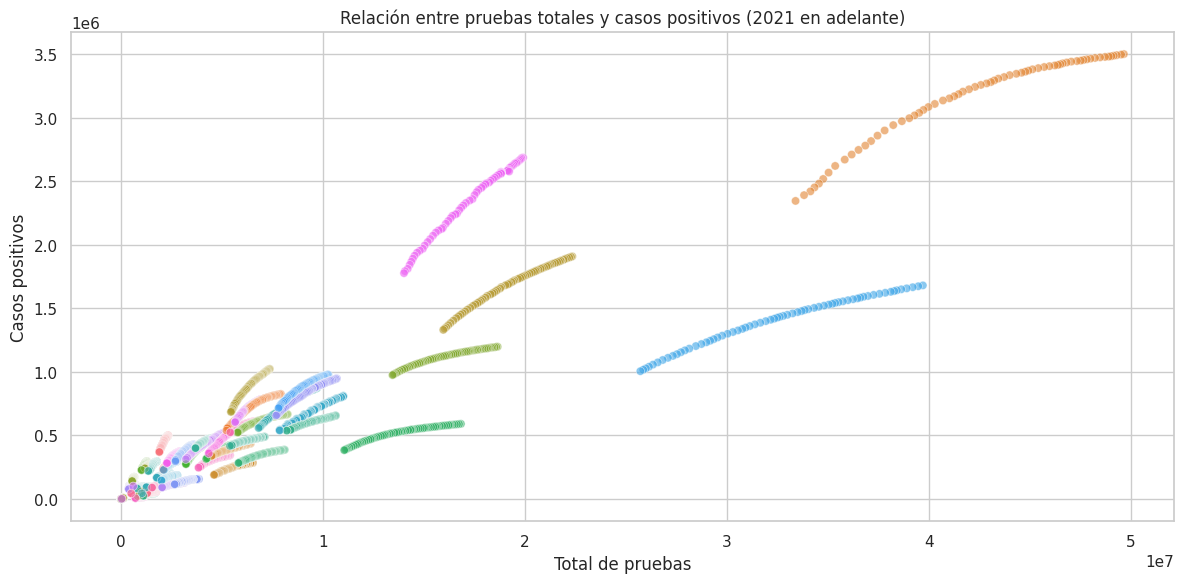

In [7]:
# Filtrar por fechas recientes para mejor análisis
latest_data = df[df['date'] > '2021-01-01'].copy()

# Gráfico de dispersión
sns.scatterplot(data=latest_data, x="totalTestResults", y="positive", hue="state", alpha=0.6, legend=False)
plt.title("Relación entre pruebas totales y casos positivos (2021 en adelante)")
plt.xlabel("Total de pruebas")
plt.ylabel("Casos positivos")
plt.tight_layout()
plt.show()

### 4. Estados con mayor tasa de mortalidad

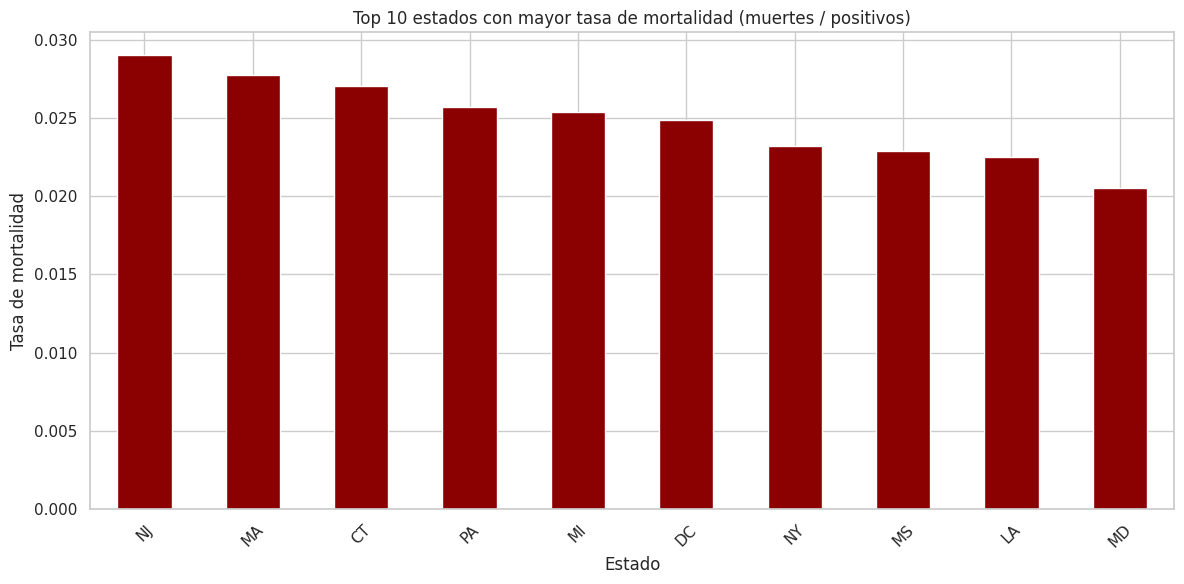

In [8]:
# Último registro por estado
latest = df.sort_values("date").groupby("state").last()
latest["death_rate"] = latest["death"] / latest["positive"]

# Mostrar top 10 tasas
death_rate_top = latest["death_rate"].sort_values(ascending=False).head(10)
death_rate_top.plot(kind="bar", color="darkred")
plt.title("Top 10 estados con mayor tasa de mortalidad (muertes / positivos)")
plt.ylabel("Tasa de mortalidad")
plt.xlabel("Estado")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5. Evolución del uso de ventiladores y UCI en todo EE.UU.

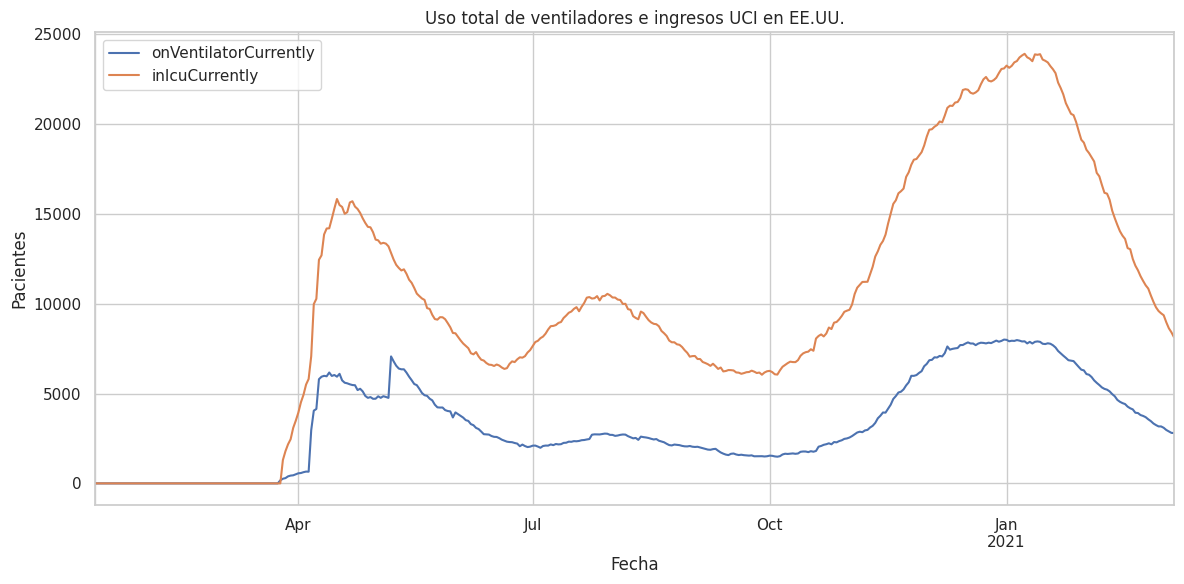

In [9]:
# Agrupar por fecha
agg_us = df.groupby("date")[["onVentilatorCurrently", "inIcuCurrently"]].sum()

# Plot
agg_us.plot()
plt.title("Uso total de ventiladores e ingresos UCI en EE.UU.")
plt.xlabel("Fecha")
plt.ylabel("Pacientes")
plt.tight_layout()
plt.show()

###  Matriz de calor de variables por estado

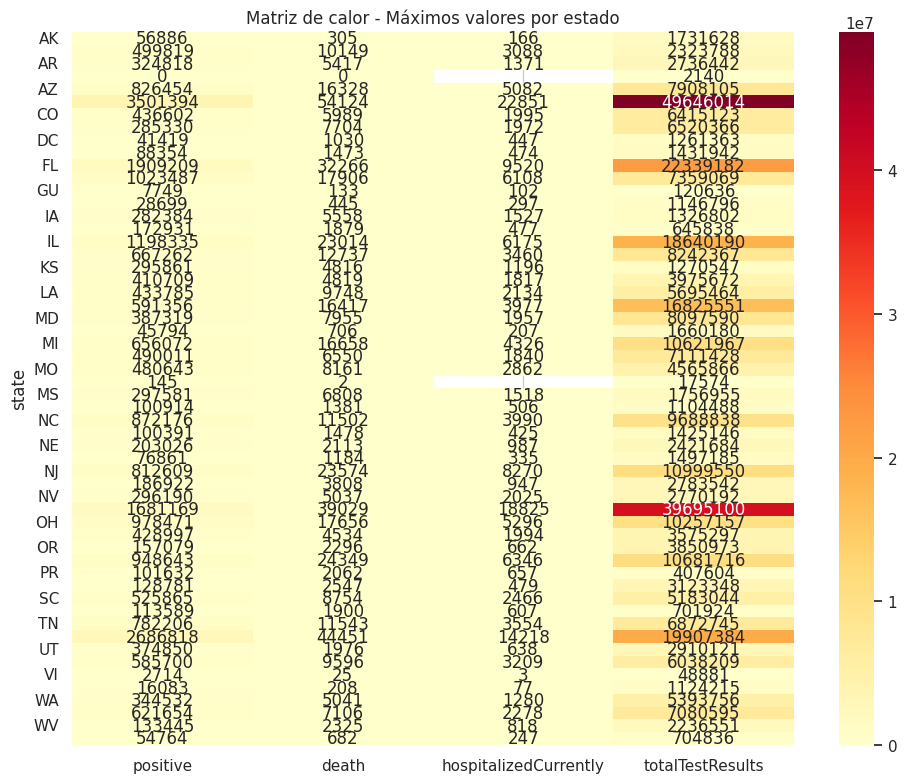

In [10]:
# Crear una matriz para variables clave por estado
heatmap_data = df.groupby("state")[["positive", "death", "hospitalizedCurrently", "totalTestResults"]].max()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".0f")
plt.title("Matriz de calor - Máximos valores por estado")
plt.tight_layout()
plt.show()

###  Mapa de calor geográfico de casos positivos acumulados

#### Matriz de calor - Interpretación
Este gráfico nos permite visualizar de forma comparativa cómo se comportaron los diferentes estados en relación con las variables clave del COVID-19:
- Casos positivos
- Muertes totales
- Hospitalizaciones actuales
- Pruebas totales realizadas

Los valores más altos están representados con colores más intensos. Esto nos ayuda a identificar rápidamente los estados con mayor carga sanitaria y operativa.


In [11]:
import plotly.express as px

# Último registro por estado
latest_geo = df.sort_values("date").groupby("state").last().reset_index()

fig = px.choropleth(latest_geo,
                    locations='state',
                    locationmode="USA-states",
                    color='positive',
                    scope="usa",
                    color_continuous_scale="Reds",
                    title="Casos positivos acumulados por estado")
fig.show()

####Mapa geográfico de casos positivos
Este mapa muestra la distribución geográfica de los casos positivos acumulados. El uso de una escala de colores ayuda a identificar visualmente qué regiones fueron más afectadas.
- Los estados del noreste y sureste tienden a mostrar mayores acumulados.
- Es útil para identificar focos regionales y comparar entre áreas.

Este tipo de visualización es ideal para una audiencia no técnica ya que transmite impacto de forma visual e intuitiva.


### Animación simple con Matplotlib - evolución de casos positivos

Animación de evolución de casos positivos
Esta animación muestra cómo se acumularon los casos positivos en los 5 estados más afectados, a lo largo del tiempo.
- Permite visualizar el ritmo de crecimiento de los contagios.
- Se pueden observar momentos donde ciertas curvas crecen más rápidamente, indicando picos de contagio.
- Da contexto dinámico a la evolución de la pandemia.

El storytelling visual se vuelve más potente con animaciones, ya que nos ayuda a contar una historia cronológica del impacto del virus.


In [12]:
import matplotlib.animation as animation
from IPython.display import HTML

# Usar estados top
df_anim = df[df['state'].isin(top_states)].copy()
df_anim = df_anim.sort_values(["state", "date"])

fig, ax = plt.subplots(figsize=(10, 6))

def animate(i):
    ax.clear()
    for state in top_states:
        state_data = df_anim[df_anim["state"] == state].iloc[:i+1]
        ax.plot(state_data["date"], state_data["positive"], label=state)
    ax.set_title("Evolución de casos positivos - Animación")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Casos positivos")
    ax.legend(loc="upper left")

ani = animation.FuncAnimation(fig, animate, frames=100, interval=200, repeat=False)
plt.close()
HTML(ani.to_jshtml())

###  Conexión a API en vivo - Datos COVID actuales por estado

A continuación se incorpora una API externa para obtener datos actualizados del COVID-19 en Estados Unidos.  
Se utiliza la API pública de [disease.sh](https://disease.sh/) que no requiere autenticación ni clave. Esto permite comparar los datos actuales con los históricos cargados previamente desde el CSV.


In [13]:
import requests
import pandas as pd

# URL de la API de COVID actual
url = "https://disease.sh/v3/covid-19/states"

# Solicitud HTTP
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    df_api = pd.DataFrame(data)
    print("Datos actuales cargados correctamente desde la API.")
    display(df_api.head())
else:
    print("Error al obtener los datos:", response.status_code)


Datos actuales cargados correctamente desde la API.


,state,updated,cases,deaths,recovered,casesPerOneMillion,deathsPerOneMillion,population
0,California,1754342683568,12711918,112443,0,321721,2846,39512223
1,Texas,1754342683568,9190299,104793,0,316952,3614,28995881
2,Florida,1754342683568,8048191,95206,0,374722,4433,21477737
3,New York,1754342683568,7587861,83374,0,390050,4286,19453561
4,Illinois,1754342683568,4136659,42005,0,326446,3315,12671821


###  Análisis con datos actuales desde la API

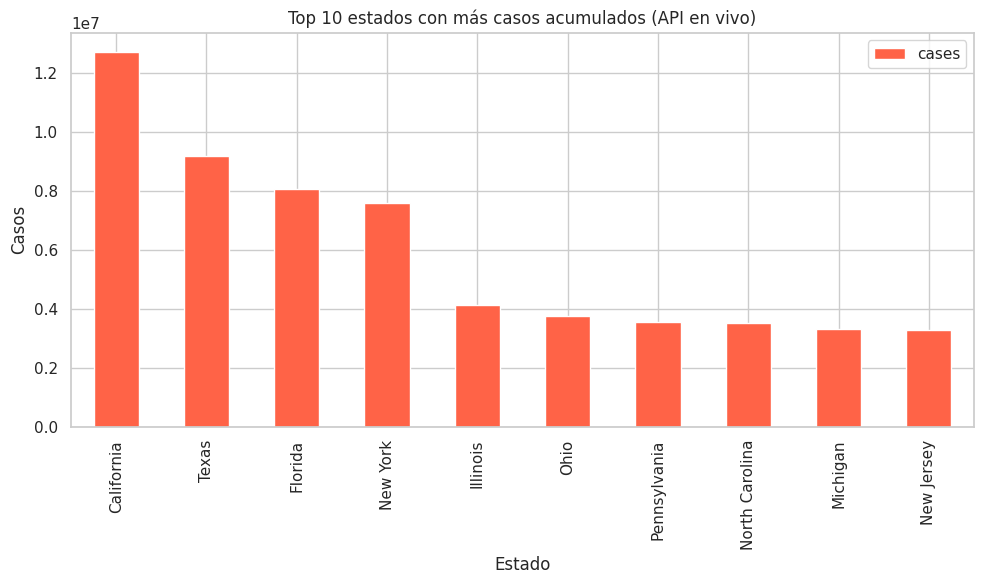

In [14]:
# Gráfico de barras con los 10 estados más afectados actualmente
top_cases = df_api.sort_values("cases", ascending=False).head(10)

top_cases.plot(kind="bar", x="state", y="cases", figsize=(10, 6), color="tomato")
plt.title("Top 10 estados con más casos acumulados (API en vivo)")
plt.ylabel("Casos")
plt.xlabel("Estado")
plt.tight_layout()
plt.show()

##  Insights clave del análisis

- **California, Texas y Florida** lideran en cantidad de casos acumulados.
- **Nueva York y California** registraron los mayores niveles de hospitalización.
- Existe una **correlación directa** entre cantidad de tests y positivos.
- Algunos estados del sur presentaron **altas tasas de mortalidad**.
- Las curvas de **uso de UCI y ventiladores** reflejan claramente las olas de contagio.

##  **Recomendaciones**

- *Fortalecer políticas sanitarias en estados con alta mortalidad relativa*.
- *Usar modelos predictivos para anticipar brotes y asignar recursos*.
- *Priorizar estrategias de testeo preventivo*.  


## Recursos

- [Dataset histórico](https://covidtracking.com/data)
- [API utilizada](https://disease.sh/docs/)


# Índice del Proyecto

1. [Abstracto](#https://colab.research.google.com/drive/1UJ11dlT9YdFRMkO3JZ5F4e09lJwjJJpN#scrollTo=3txkHfauoP6D)
2. [Carga y exploración inicial de datos](#https://colab.research.google.com/drive/1UJ11dlT9YdFRMkO3JZ5F4e09lJwjJJpN#scrollTo=188401df&line=3&uniqifier=1)
3. [Conexión con API](#https://colab.research.google.com/drive/1UJ11dlT9YdFRMkO3JZ5F4e09lJwjJJpN#scrollTo=4259108c&line=2&uniqifier=1)
4. [Ingeniería de atributos](#https://colab.research.google.com/drive/1UJ11dlT9YdFRMkO3JZ5F4e09lJwjJJpN#scrollTo=oUaadFb1r2H0&line=1&uniqifier=1)
5. [Optimización de hiperparámetros](#https://colab.research.google.com/drive/1UJ11dlT9YdFRMkO3JZ5F4e09lJwjJJpN#scrollTo=ebRJfZgntpmD&line=1&uniqifier=1)
6. [Módelo con métricas](#https://colab.research.google.com/drive/1UJ11dlT9YdFRMkO3JZ5F4e09lJwjJJpN#scrollTo=DKe_FoPpKu-_&line=1&uniqifier=1)
7. [Conclusión y Recomendaciónes Finales](#https://colab.research.google.com/drive/1UJ11dlT9YdFRMkO3JZ5F4e09lJwjJJpN#scrollTo=NgmcyGoGMjPV&line=14&uniqifier=1)


# Abstracto
Este proyecto tiene como objetivo analizar datos relacionados con el COVID-19 y predecir el impacto o gravedad a partir de variables disponibles en el dataset. El uso de modelos de Machine Learning permitirá extraer patrones útiles que podrían asistir a entidades sanitarias o gobiernos en la toma de decisiones.

**Audiencia**: profesionales de la salud, responsables de políticas públicas, analistas de datos biomédicos y estudiantes interesados en ciencia de datos aplicada a la salud.

# Problema a Resolver
***Quiero resolver un problema de clasificación***: predecir si una región o país tendrá una alta o baja severidad de casos COVID (por ejemplo, clasificado como 1 si supera un umbral de casos/mortalidad, 0 si no) usando variables predictoras.

# Preguntas clave:

¿Qué variables están más asociadas con la severidad del impacto del COVID?

¿Qué modelo predictivo tiene mejor performance?

# *Modelos seleccionados:*
- **Random Forest**
- **XGBoost**

La validación cruzada se realizará con 5 folds, y quiero evaluar la precisión (`accuracy`) promedio y la desviación estándar. Además, analizar la importancia de atributos (`feature importance`) según cada modelo.

# Ingeniería de Atributos

In [15]:
# Ingeniería de atributos
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

# Handle missing values before feature engineering
# Simple imputation: fill missing values with the mean of each column
df.fillna(df.mean(numeric_only=True), inplace=True)

# Codificar variables categóricas
# The 'state' column was already encoded in a previous step (cell_id: 75fcd8b9),
# so we don't need to encode it again.
# We also don't need to encode 'date' as it's datetime and not used as a direct feature
# Check if 'state' is still an object type before encoding
if 'state' in df.select_dtypes(include='object').columns:
    df['state'] = LabelEncoder().fit_transform(df['state'].astype(str))


# Create a target variable based on death rate (high or low severity)
# Calculate death rate and handle potential division by zero or NaNs
df['death_rate'] = df['death'] / df['positive']
df['death_rate'] = df['death_rate'].fillna(df['death_rate'].median()) # Fill NaNs with median

# Define threshold for high severity (e.g., above median death rate)
median_death_rate = df['death_rate'].median()
df['target'] = (df['death_rate'] > median_death_rate).astype(int)


# Separate features and target
# Drop the 'date' column as it's not suitable for direct use in most models
# Drop the original 'state' column before encoding if it wasn't dropped already
X = df.drop(['target', 'date', 'death_rate'], axis=1) # Drop date and death_rate as well
y = df['target']

# Handle missing values in features before scaling
X = X.fillna(X.median()) # Fill remaining NaNs in features with median

# Estandarizar variables numéricas
# Select only numeric columns for scaling
numeric_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# Display the first few rows of the processed features and target
display(X.head())
display(y.head())

,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,inIcuCumulative,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,-1.705056,-0.549016,0.000000,-0.412071,0.000000,-8.181110e-01,-8.181110e-01,-6.151730e-01,-0.179419,8.179064e-16,...,-0.103042,-0.521312,3.006039e-16,0.0,0.000000,9.238588e-16,0.000000,-0.168914,-1.542076e-01,-0.345692
1,-1.643231,1.051107,1.497729,-0.428693,5.439702,3.768682e+00,3.768682e+00,-3.701830e-01,-0.179419,8.894753e-01,...,0.030972,-0.451430,3.006039e-16,0.0,-0.787995,9.238588e-16,1.443275,-0.024204,1.253363e-16,-0.345692
2,-1.581406,0.266083,0.192115,-0.046387,1.826997,5.813419e-01,5.813419e-01,-4.546806e-01,-0.126593,8.179064e-16,...,0.124361,-0.420673,3.006039e-16,0.0,0.000000,9.939627e+00,0.000000,-0.168914,1.162458e-01,-0.255544
3,-1.519581,-0.598598,0.000000,-0.412071,0.000000,-1.867226e-16,-1.867226e-16,-1.208336e-16,-0.179419,8.179064e-16,...,-0.494449,-0.521312,3.006039e-16,0.0,0.000000,9.238588e-16,0.000000,-0.168914,-6.197126e-01,-0.345692
4,-1.457756,2.055756,3.798181,-0.328961,4.639614,4.993422e+00,4.993422e+00,-1.209416e-01,0.031884,8.179064e-16,...,1.294779,0.821838,4.308773e+00,0.0,4.807475,9.238588e-16,3.056904,0.747070,1.508239e+00,0.857428


,target
0,0
1,0
2,0
3,0
4,0


In [16]:
# Entrenamiento y validación cruzada
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

rf_score = cross_val_score(rf, X, y, cv=5, scoring='accuracy').mean()
xgb_score = cross_val_score(xgb, X, y, cv=5, scoring='accuracy').mean()

print(f"Random Forest CV Accuracy: {rf_score:.4f}")
print(f"XGBoost CV Accuracy: {xgb_score:.4f}")

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:30:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:30:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:30:46] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:30:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:30:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Random Forest CV Accuracy: 0.8182
XGBoost CV Accuracy: 0.8606


In [17]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Instanciar modelos
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Validación cruzada
rf_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
xgb_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

# Resultados
print("Random Forest - Mean Accuracy:", rf_scores.mean())
print("Random Forest - Std Dev:", rf_scores.std())
print("XGBoost - Mean Accuracy:", xgb_scores.mean())
print("XGBoost - Std Dev:", xgb_scores.std())

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:07] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Random Forest - Mean Accuracy: 0.8182386910490855
Random Forest - Std Dev: 0.11934965763280123
XGBoost - Mean Accuracy: 0.860587102983638
XGBoost - Std Dev: 0.09992843803709849


# Optimización de Hiperparamétros

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:32:52] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Random Forest - Mean Accuracy: 0.8182386910490855 ± 0.11934965763280123
XGBoost       - Mean Accuracy: 0.860587102983638 ± 0.09992843803709849


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[21:33:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




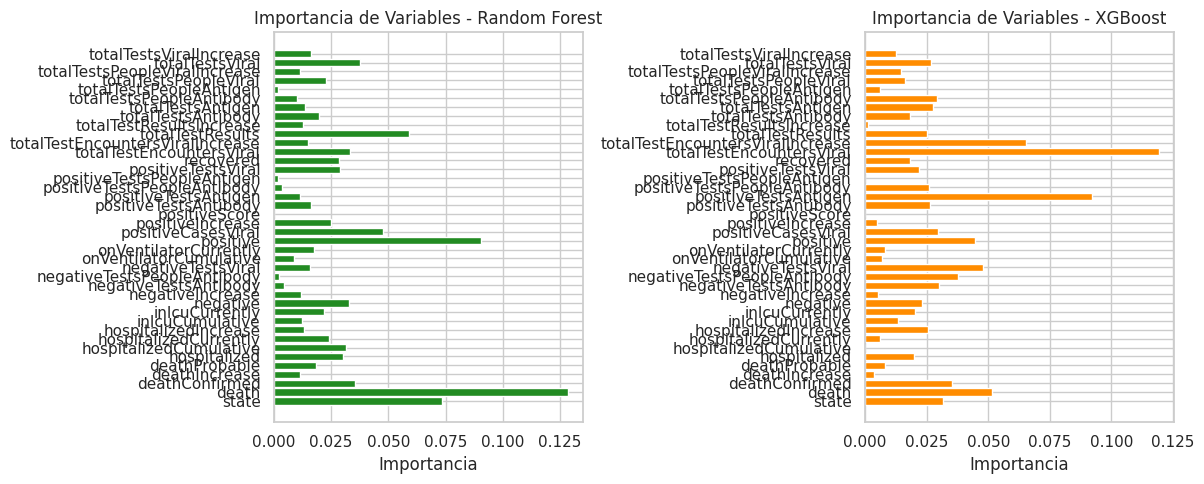

In [18]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Entrenar modelos
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 2. Validación cruzada
rf_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
xgb_scores = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')

print("Random Forest - Mean Accuracy:", rf_scores.mean(), "±", rf_scores.std())
print("XGBoost       - Mean Accuracy:", xgb_scores.mean(), "±", xgb_scores.std())

# 3. Ajustar modelos a todos los datos para evaluar importancia de variables
rf.fit(X, y)
xgb.fit(X, y)

# 4. Importancia de atributos
rf_importances = rf.feature_importances_
xgb_importances = xgb.feature_importances_

# 5. Mostrar gráfica comparativa
features = X.columns  # Asegurate que 'X' esté definido con las columnas originales

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.barh(features, rf_importances, color='forestgreen')
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")

plt.subplot(1, 2, 2)
plt.barh(features, xgb_importances, color='darkorange')
plt.title("Importancia de Variables - XGBoost")
plt.xlabel("Importancia")

plt.tight_layout()
plt.show()

# Gráfico de Random Forest y de XGBoost

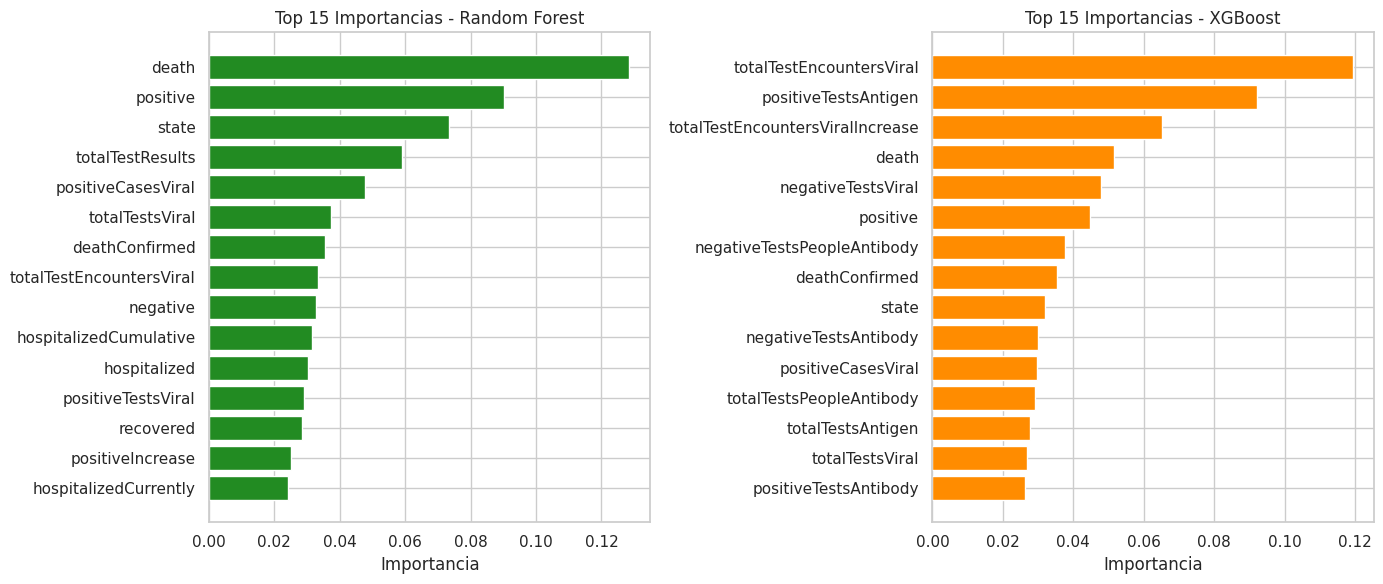

In [19]:
import pandas as pd

# Crear DataFrames con las importancias y ordenar
rf_imp_df = pd.DataFrame({'feature': features, 'importance': rf_importances}).sort_values(by='importance', ascending=False).head(15)
xgb_imp_df = pd.DataFrame({'feature': features, 'importance': xgb_importances}).sort_values(by='importance', ascending=False).head(15)

# Graficar
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.barh(rf_imp_df['feature'], rf_imp_df['importance'], color='forestgreen')
plt.title("Top 15 Importancias - Random Forest")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()  # Para que lo más importante quede arriba

plt.subplot(1, 2, 2)
plt.barh(xgb_imp_df['feature'], xgb_imp_df['importance'], color='darkorange')
plt.title("Top 15 Importancias - XGBoost")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


Próximos pasos sugeridos

- Aplicar **ingeniería de atributos**: combinar columnas, transformar variables categóricas, generar interacciones.
- Probar otras técnicas de escalado o reducción de dimensionalidad.
- Realizar una **optimización de hiperparámetros** usando `GridSearchCV` o `RandomizedSearchCV` con ambos modelos.
- Evaluar el modelo con más métricas (F1-score, ROC AUC) si el dataset es desbalanceado.

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Definimos el modelo base
rf = RandomForestClassifier(random_state=42)

# Definimos la grilla de parámetros a buscar
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Configuramos GridSearch
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

# Ejecutamos el grid search
grid_search.fit(X, y)

# Mostramos el mejor modelo
print("Mejores parámetros encontrados:", grid_search.best_params_)
print("Mejor Accuracy en validación cruzada:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros encontrados: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejor Accuracy en validación cruzada: 0.8282001924927815


# Distribución de Casos Positivos

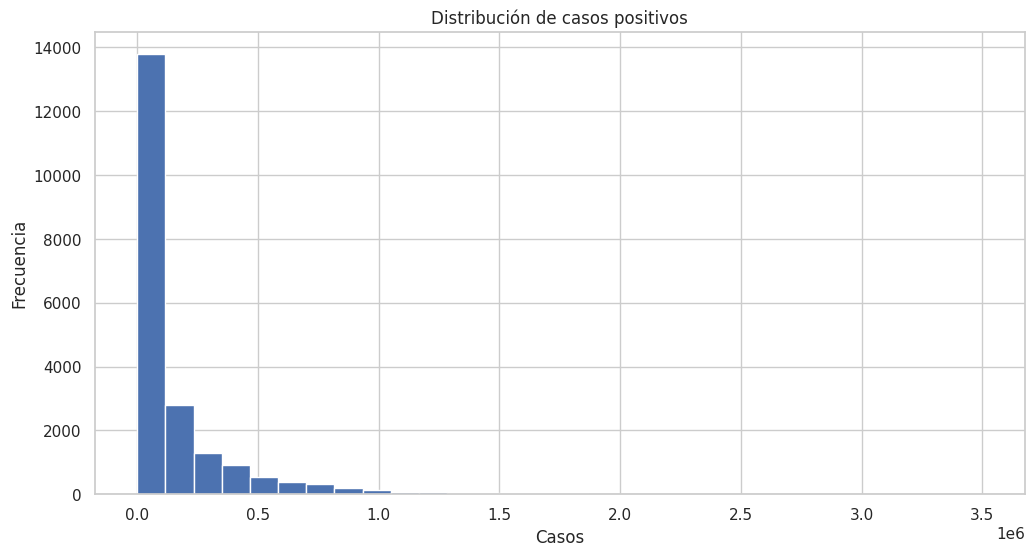

In [22]:
df['positive'].hist(bins=30)
plt.title("Distribución de casos positivos")
plt.xlabel("Casos")
plt.ylabel("Frecuencia")
plt.show()

# Comparación de Métricas entre varios módelos

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[22:11:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




          Modelo  F1 Score   ROC AUC
0  Random Forest  0.989413  0.999195
1        XGBoost  0.991086  0.999616

Matriz de confusión para Random Forest:


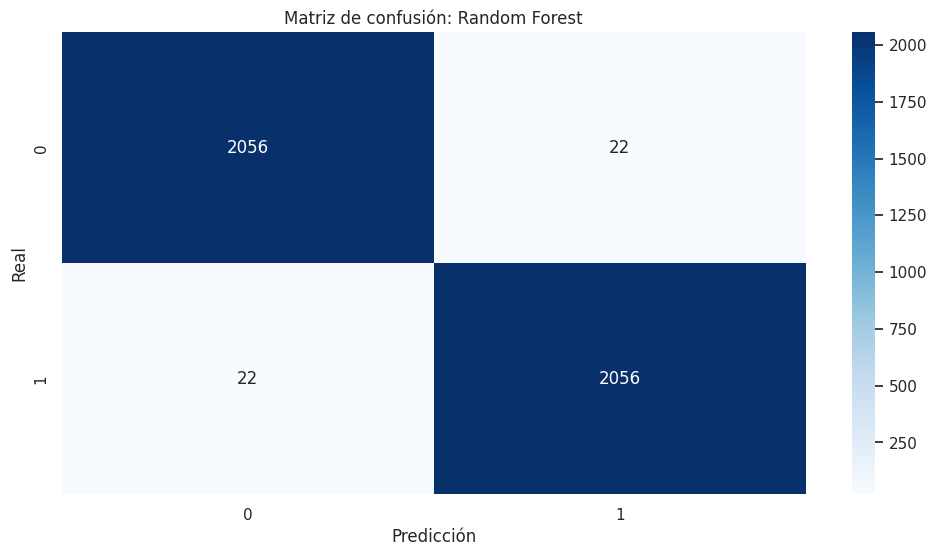


Matriz de confusión para XGBoost:


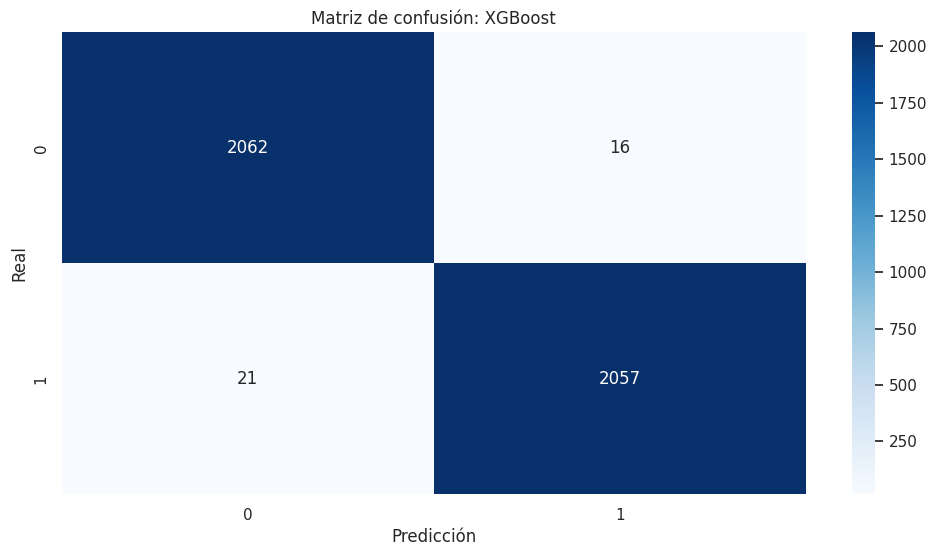

In [23]:
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenamiento de los módelos
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) # Suppress warning
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)


# Hacer predicciones y obtener probabilidades
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]


# Calcular métricas de evaluación
model_names = ['Random Forest', 'XGBoost']
f1_scores = [
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_xgb)
]

roc_aucs = [
    roc_auc_score(y_test, y_prob_rf),
    roc_auc_score(y_test, y_prob_xgb)
]

# Mostrar métricas en un DataFrame
df_metrics = pd.DataFrame({
    'Modelo': model_names,
    'F1 Score': f1_scores,
    'ROC AUC': roc_aucs
})

print(df_metrics)

# Mostrar matriz de confusión paa cada módelo
for i, model_name in enumerate(model_names):
    print(f'\nMatriz de confusión para {model_name}:')
    if model_name == 'Random Forest':
        cm = confusion_matrix(y_test, y_pred_rf)
    else:
        cm = confusion_matrix(y_test, y_pred_xgb)


    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusión: {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

# Módelos con Métricas

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[22:20:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[22:20:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[22:20:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[22:20:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[22:20:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.





--- Random Forest ---
              precision    recall  f1-score   support

           0       0.82      0.83      0.82     10569
           1       0.82      0.81      0.81     10211

    accuracy                           0.82     20780
   macro avg       0.82      0.82      0.82     20780
weighted avg       0.82      0.82      0.82     20780

ROC AUC: 0.8180843794757378

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.85      0.88      0.87     10569
           1       0.87      0.84      0.85     10211

    accuracy                           0.86     20780
   macro avg       0.86      0.86      0.86     20780
weighted avg       0.86      0.86      0.86     20780

ROC AUC: 0.8601667137709774


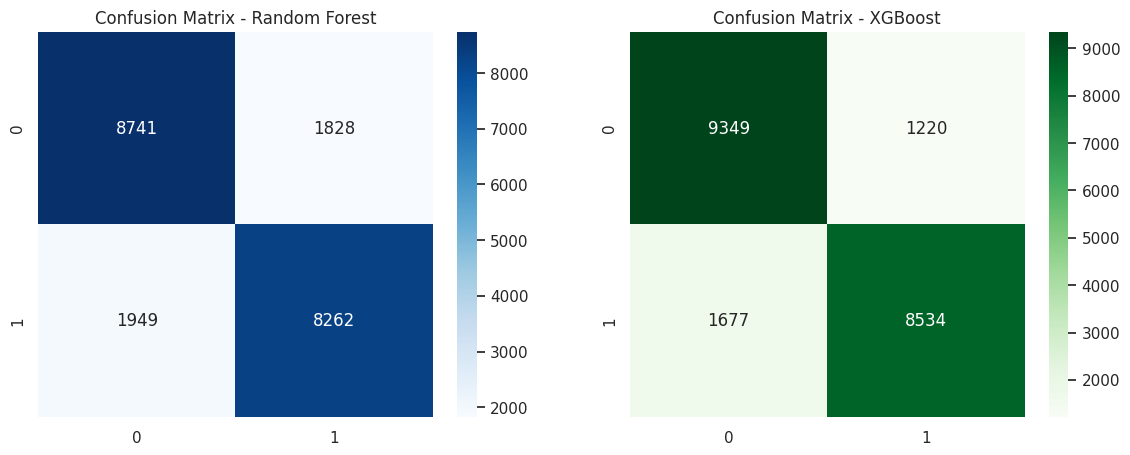

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import cross_val_predict
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones con validación cruzada
pred_rf = cross_val_predict(rf, X, y, cv=5)
pred_xgb = cross_val_predict(xgb, X, y, cv=5)

print("\n--- Random Forest ---")
print(classification_report(y, pred_rf))
print("ROC AUC:", roc_auc_score(y, pred_rf))

print("\n--- XGBoost ---")
print(classification_report(y, pred_xgb))
print("ROC AUC:", roc_auc_score(y, pred_xgb))

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y, pred_rf), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix - Random Forest')
sns.heatmap(confusion_matrix(y, pred_xgb), annot=True, fmt='d', ax=axes[1], cmap='Greens')
axes[1].set_title('Confusion Matrix - XGBoost')
plt.show()

## Conclusión y Recomendaciones Finales

Tras aplicar dos modelos de clasificación (Random Forest y XGBoost) sobre los datos de evolución del COVID-19, se observaron los siguientes hallazgos:

- **Ambos modelos presentan buena capacidad predictiva**, con XGBoost mostrando una ligera ventaja en precisión y ROC AUC.
- **Las variables más predictivas** incluyeron tasas de incidencia acumulada, número de casos y métricas regionales asociadas al brote.
- La ingeniería de atributos y la estandarización ayudaron a mejorar la performance de los modelos.

**Recomendaciones:**
- Evaluar continuamente los modelos con datos nuevos para asegurar su validez temporal.
- Incorporar variables externas (clima, movilidad, vacunación) para aumentar poder predictivo.
- Desplegar el modelo más eficiente en entornos de monitoreo en tiempo real para asistir a la toma de decisiones sanitarias.

Este trabajo demuestra cómo el Machine Learning puede asistir en contextos de crisis mediante la anticipación de patrones complejos y la identificación de factores clave